# Tools

## 0. Setup

In [1]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
# model = "bedrock/anthropic.claude-4-5-sonnet"
model = "bedrock/anthropic.claude-4-5-haiku"

In [2]:
# Helper functions
from anthropic.types import Message


def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message


def text_from_message(message):
    return "\n".join([block.text for block in message.content if block.type == "text"])

## Setting Up the Web Search Tool

To use the web search tool, you create a schema object with these required fields:

The max_uses field limits how many searches Claude can perform. Claude might do follow-up searches based on initial results, so this prevents excessive API calls. A single search returns multiple results, but Claude may decide additional searches are needed.

### Restricting Search Domains

You can limit searches to specific domains using the allowed_domains field. This is particularly useful when you want reliable, authoritative sources:



In [3]:
web_search_schema = {
    "type": "web_search_20250305",
    "name": "web_search",
    "max_uses": 5,
    "allowed_domains": ["nih.gov"],
}

## How the Response Works

When Claude uses the web search tool, the response contains several types of blocks:

- Text blocks - Claude's explanation of what it's doing
- ServerToolUseBlock - Shows the exact search query Claude used
- WebSearchToolResultBlock - Contains the search results
- WebSearchResultBlock - Individual search results with titles and URLs
- Citation blocks - Text that supports Claude's statements


In [5]:
messages = []
add_user_message(
    messages,
    """
    What's the best exercise for gaining leg muscle?
    """,
)
response = chat(messages, tools=[web_search_schema])
response

RateLimitError: Error code: 429 - {'error': {'message': '{"timestamp":"2026-07-22T11:25:59.497Z","path":"/ai-orchestration-api/v1/bedrock/invoke","status":429,"error":{"source":"internal","classification":"USER_QUOTA_EXCEEDED","message":"Your request rate limit has been exceeded. Please wait 822841s.","retryAfter":822841,"retryGuidance":"Contact tenant admin to upgrade your plan or increase your contract limits. Retry after 822841 seconds.","affectedProvider":"bedrock"}}. Received Model Group=bedrock/anthropic.claude-4-5-haiku\nAvailable Model Group Fallbacks=None', 'type': 'None', 'param': 'None', 'code': '429'}}

## Rendering Search Results

The different block types in the response are designed for specific UI rendering:

Render text blocks as regular content
Display web search results as a list of sources at the top
Show citations inline with the text, including the source domain, page title, URL, and quoted text

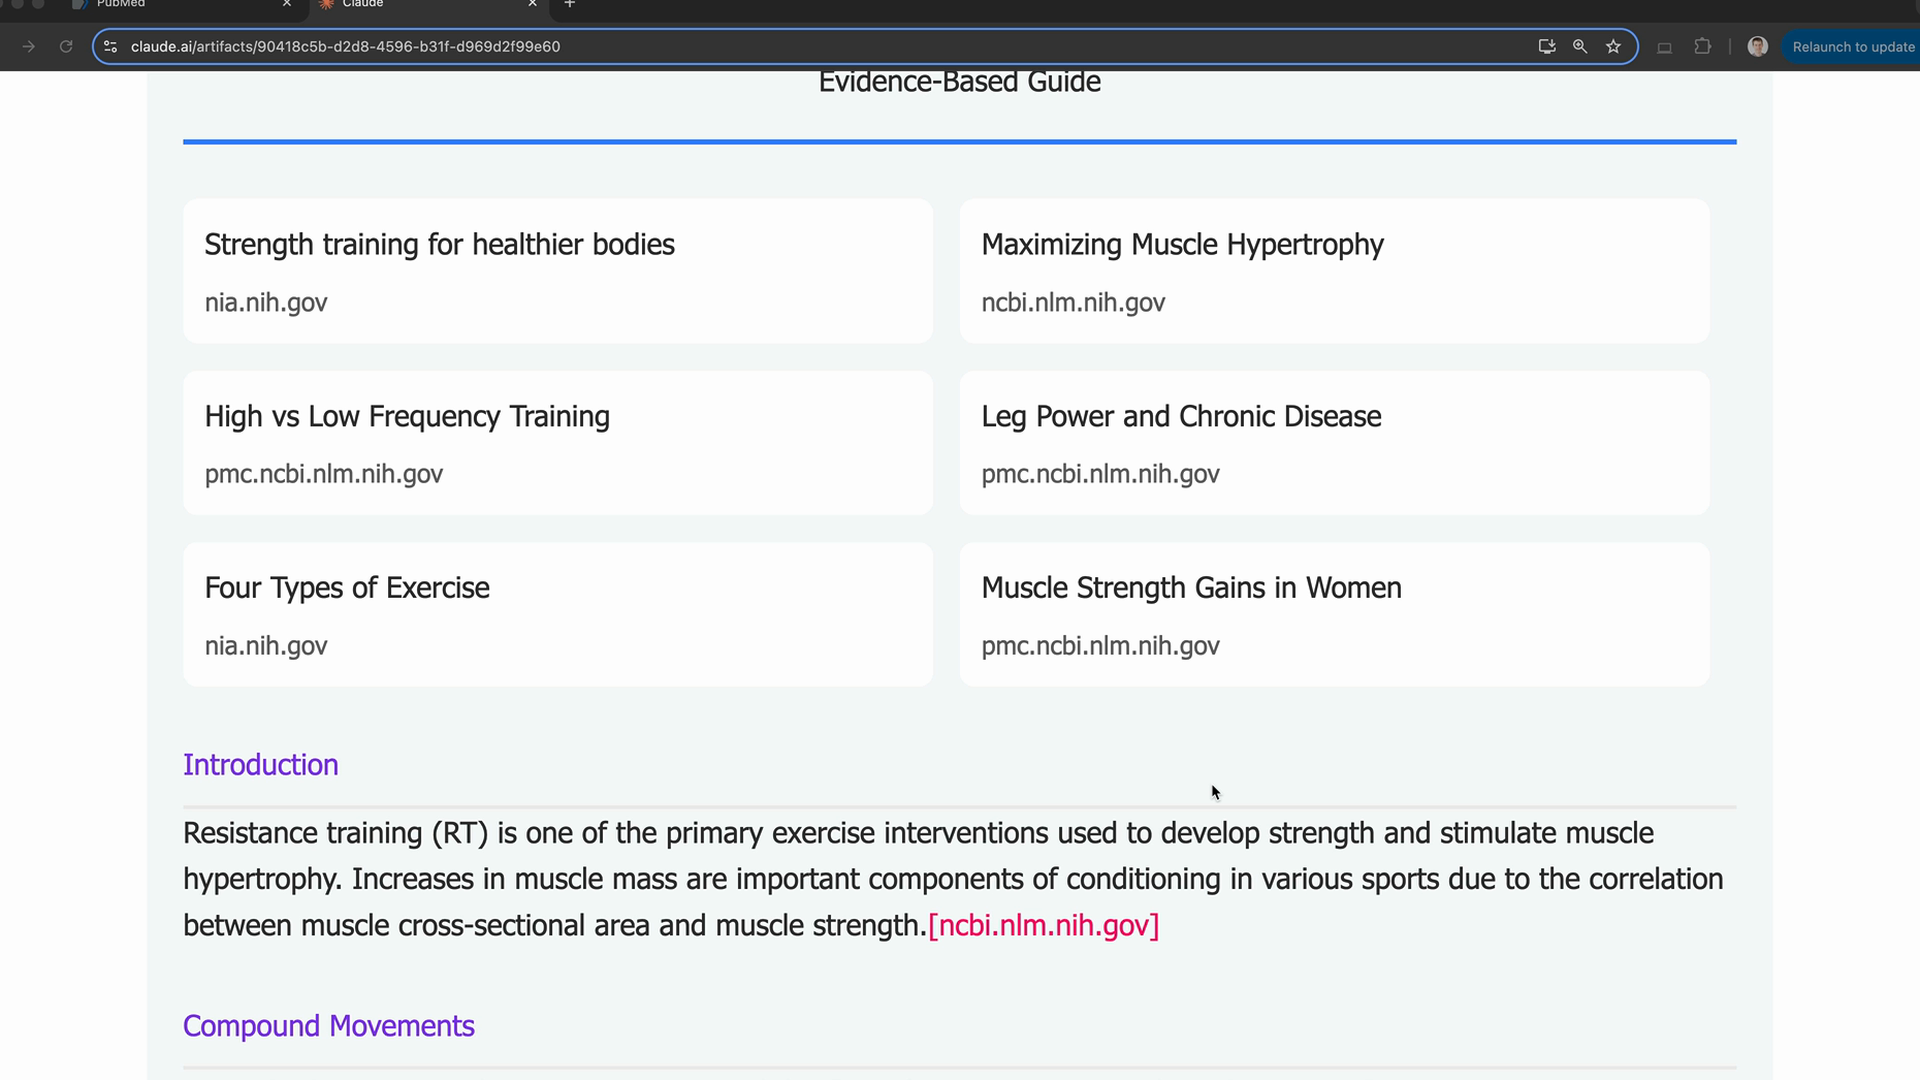

This structure helps users understand how Claude arrived at its answers and provides transparency about the sources being used. The citation format makes it clear which specific information came from which sources, building trust in the AI's responses.

